In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle
import os
import anthropic
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



In [4]:
# Load Season A
df_crop_a = pd.read_stata('../data/STATA/rwa-sas-seasonA_Crop production.dta', convert_categoricals=True)
df_fert_a = pd.read_stata('../data/STATA/rwa-sas-SeasonA_PartIII_Fertilizers_Pesticides.dta', convert_categoricals=True)

# Add Season Tag
df_crop_a['Season_Type'] = 'Season A'
df_fert_a['Season_Type'] = 'Season A'

print(f"✅ Season A Loaded: {df_crop_a.shape[0]} crop records.")


✅ Season A Loaded: 41589 crop records.


In [5]:
# Load Season B
df_crop_b = pd.read_stata('../data/STATA/rwa-sas-seasonB_Crop production.dta', convert_categoricals=True)
df_fert_b = pd.read_stata('../data/STATA/rwa-sas-SeasonB_PartIII_Fertilizers_Pesticides.dta', convert_categoricals=True)

# Add Season Tag
df_crop_b['Season_Type'] = 'Season B'
df_fert_b['Season_Type'] = 'Season B'

print(f"✅ Season B Loaded: {df_crop_b.shape[0]} crop records.")


✅ Season B Loaded: 36005 crop records.


In [6]:
# Combine seasons
df_crop_master = pd.concat([df_crop_a, df_crop_b], ignore_index=True)
df_fert_master = pd.concat([df_fert_a, df_fert_b], ignore_index=True)

print(f"✅ Master Dataset Created.")
print(f"Total Combined Records: {df_crop_master.shape[0]}")


✅ Master Dataset Created.
Total Combined Records: 77594


In [7]:
# Unique keys to link records correctly
merge_keys = ['Segment_ID', 's2q1', 's1q1', 's1q2', 'Season_Type']

# Inner join to ensure we only have plots with both crop and fertilizer info
df_merged = pd.merge(df_crop_master, df_fert_master, on=merge_keys, how='inner', suffixes=('_crop', '_fert'))

print(f"✅ Merge Complete: {df_merged.shape[0]} joined records.")


✅ Merge Complete: 101259 joined records.


In [8]:
# Based on the SAS standard codes we identified earlier
rename_dict = {
    's1q1': 'Province',
    's1q2': 'District',
    'Season_Type': 'Season',
    's2q9': 'Plot_Slope', 
    's2q11': 'Seed_Type',
    'CropCategory': 'Target_Crop',
    'yield': 'Yield',
    's3q1': 'Inorganic_Fert',
    's3q11': 'Organic_Fert',
    's3q19': 'Used_Lime'
}

# Apply rename
df_im = df_merged.rename(columns=rename_dict)

# Select only the high-impact columns for our model
core_columns = [
    'Province', 'District', 'Season', 'Plot_Slope', 
    'Seed_Type', 'Target_Crop', 'Yield', 
    'Inorganic_Fert', 'Organic_Fert', 'Used_Lime'
]

# Create our working dataframe
df_im = df_im[core_columns]

print(f"✅ Columns Selected and Renamed.")
print(f"Dataset Shape: {df_im.shape}")
df_im.head()


✅ Columns Selected and Renamed.
Dataset Shape: (101259, 10)


,Province,District,Season,Plot_Slope,Seed_Type,Target_Crop,Yield,Inorganic_Fert,Organic_Fert,Used_Lime
0,Kigali,Gasabo,Season A,No,Traditional seeds,Bush bean,960.008118,Yes,NaN,No
1,Kigali,Gasabo,Season A,No,Traditional seeds,Bush bean,1269.844971,Yes,NaN,No
2,Kigali,Gasabo,Season A,No,Traditional seeds,Sweet potato,15271.156250,Yes,NaN,No
3,Kigali,Gasabo,Season A,Yes,Improved seeds,Vegetables,34988.839844,Yes,NaN,No
4,Kigali,Gasabo,Season A,Yes,Improved seeds,Vegetables,29982.449219,Yes,NaN,No


In [9]:
# 1. Convert categorical columns to strings to handle missing values safely
categorical_cols = ['Province', 'District', 'Season', 'Plot_Slope', 'Seed_Type', 'Inorganic_Fert', 'Organic_Fert', 'Used_Lime']
for col in categorical_cols:
    df_im[col] = df_im[col].astype(str).replace('nan', 'No')

# 2. Clean the Yield column (keeping only realistic positive yields)
df_im = df_im[df_im['Yield'] > 0]

# 3. Map Binary values (Yes=1, No=0)
binary_map = {'Yes': 1, 'No': 0}
for col in ['Inorganic_Fert', 'Organic_Fert', 'Used_Lime']:
    df_im[col] = df_im[col].map(binary_map)

# 4. Remove any rows that failed the mapping
df_im = df_im.dropna()

print(f"✅ Data Cleaning Complete.")
print(f"Final records for training: {len(df_im)}")
df_im.head()


✅ Data Cleaning Complete.
Final records for training: 49505


,Province,District,Season,Plot_Slope,Seed_Type,Target_Crop,Yield,Inorganic_Fert,Organic_Fert,Used_Lime
0,Kigali,Gasabo,Season A,No,Traditional seeds,Bush bean,960.008118,1,0.0,0
1,Kigali,Gasabo,Season A,No,Traditional seeds,Bush bean,1269.844971,1,0.0,0
2,Kigali,Gasabo,Season A,No,Traditional seeds,Sweet potato,15271.156250,1,0.0,0
3,Kigali,Gasabo,Season A,Yes,Improved seeds,Vegetables,34988.839844,1,0.0,0
4,Kigali,Gasabo,Season A,Yes,Improved seeds,Vegetables,29982.449219,1,0.0,0


In [10]:
# Initialize a new set of encoders for our expanded dataset
le_province = LabelEncoder()
le_district = LabelEncoder()
le_season = LabelEncoder()
le_slope = LabelEncoder()
le_seeds = LabelEncoder()
le_crop = LabelEncoder()

# Apply encoding to all text columns
df_im['Province_Enc'] = le_province.fit_transform(df_im['Province'])
df_im['District_Enc'] = le_district.fit_transform(df_im['District'])
df_im['Season_Enc'] = le_season.fit_transform(df_im['Season'])
df_im['Slope_Enc'] = le_slope.fit_transform(df_im['Plot_Slope'])
df_im['Seeds_Enc'] = le_seeds.fit_transform(df_im['Seed_Type'])
df_im['Crop_Enc'] = le_crop.fit_transform(df_im['Target_Crop'])

print("✅ Encoding Complete for all Seasons and Features.")
print(f"Seasons identified: {le_season.classes_}")
print(f"Number of Crops: {len(le_crop.classes_)}")

# Preview the encoded mapping
df_im[['Province', 'Province_Enc', 'Season', 'Season_Enc', 'Target_Crop', 'Crop_Enc']].head()


✅ Encoding Complete for all Seasons and Features.
Seasons identified: ['Season A' 'Season B']
Number of Crops: 21


,Province,Province_Enc,Season,Season_Enc,Target_Crop,Crop_Enc
0,Kigali,1,Season A,0,Bush bean,1
1,Kigali,1,Season A,0,Bush bean,1
2,Kigali,1,Season A,0,Sweet potato,17
3,Kigali,1,Season A,0,Vegetables,19
4,Kigali,1,Season A,0,Vegetables,19


In [11]:
# 1. Filter for High-Yield (Successful) Records
crop_medians = df_im.groupby('Target_Crop')['Yield'].transform('median')
df_success = df_im[df_im['Yield'] >= crop_medians].copy()

# 2. Define our Features (X) and Target (y)
# Note: We now include 'Season_Enc' as a professional precision feature
features = ['Province_Enc', 'District_Enc', 'Season_Enc', 'Slope_Enc', 'Seeds_Enc', 'Inorganic_Fert', 'Organic_Fert', 'Used_Lime']
X = df_success[features]
y = df_success['Crop_Enc']

# 3. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Refined for Success.")
print(f"Training on {len(X_train)} high-performance records.")


✅ Data Refined for Success.
Training on 19805 high-performance records.


C:\Users\davide\AppData\Local\Temp\ipykernel_12908\346285062.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crop_medians = df_im.groupby('Target_Crop')['Yield'].transform('median')


In [12]:
# Initialize the Precision Random Forest
# We use 300 trees (n_estimators) for better reliability with seasonal data
rf_seasonal = RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42)

print("⏳ Training the Season-Aware Model... (This may take a minute)")
rf_seasonal.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_seasonal.predict(X_test)
seasonal_accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Training Complete!")
print(f"Refined Seasonal Model Accuracy: {seasonal_accuracy * 100:.2f}%")


⏳ Training the Season-Aware Model... (This may take a minute)
✅ Training Complete!
Refined Seasonal Model Accuracy: 28.74%


In [13]:
# 1. Ensure the models directory exists
model_dir = '../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 2. Save the Season-Aware Model
with open(f'{model_dir}/crop_model_seasonal.pkl', 'wb') as f:
    pickle.dump(rf_seasonal, f)

# 3. Save the All-New Encoders (Including Season)
seasonal_encoders = {
    'province': le_province,
    'district': le_district,
    'season': le_season,
    'slope': le_slope,
    'seeds': le_seeds,
    'crop': le_crop
}

with open(f'{model_dir}/encoders_seasonal.pkl', 'wb') as f:
    pickle.dump(seasonal_encoders, f)

print("✅ Season-Aware Model & Encoders Saved!")
print(f"Features trained: {features}")


✅ Season-Aware Model & Encoders Saved!
Features trained: ['Province_Enc', 'District_Enc', 'Season_Enc', 'Slope_Enc', 'Seeds_Enc', 'Inorganic_Fert', 'Organic_Fert', 'Used_Lime']


In [14]:
import pickle
import anthropic
import numpy as np
import pandas as pd

# 1. LOAD THE SEASONAL BRAIN
# We specifically use the 'seasonal' versions to ensure 'Correctness'
with open('../models/crop_model_seasonal.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/encoders_seasonal.pkl', 'rb') as f:
    encoders = pickle.load(f)

# 2. INITIALIZE CLAUDE (Using your CBC Key)
client = anthropic.Anthropic(api_key="YOUR_KEY_HERE")

def get_final_advice(province, district, season, slope, seeds, inorganic, organic, lime):
    try:
        # Transform inputs into the numbers the brain understands
        p_enc = encoders['province'].transform([province])
        d_enc = encoders['district'].transform([district])
        s_enc = encoders['season'].transform([season])
        sl_enc = encoders['slope'].transform([slope])
        sd_enc = encoders['seeds'].transform([seeds])
        
        # Prepare the features exactly as we trained them
        feature_names = ['Province_Enc', 'District_Enc', 'Season_Enc', 'Slope_Enc', 'Seeds_Enc', 'Inorganic_Fert', 'Organic_Fert', 'Used_Lime']
        input_df = pd.DataFrame([[p_enc, d_enc, s_enc, sl_enc, sd_enc, inorganic, organic, lime]], columns=feature_names)
        
        # Predict the most successful crop
        crop_id = model.predict(input_df)
        recommended_crop = encoders['crop'].inverse_transform(crop_id)[0]
        
        # 3. GET THE KINYARWANDA ADVICE
        prompt = f"Wowe uri umuhanga mu buhinzi... [Prompt for {recommended_crop} in {season} at {district}]"
        
        # For now, let's just verify the prediction works
        return recommended_crop, "Claude Advice Engine Ready!"

    except Exception as e:
        return None, str(e)

# --- TEST ---
crop, status = get_final_advice("Kigali", "Gasabo", "Season A", "No", "Traditional seeds", 1, 1, 0)
print(f"✅ Final Seasonal Prediction: {crop}")


✅ Final Seasonal Prediction: Bush bean


In [15]:
# Use Windows-specific commands to move the archive files
!if not exist "..\models\archive" mkdir "..\models\archive"
!move "..\models\*precision.pkl" "..\models\archive\"


A duplicate file name exists, or the file
cannot be found.


In [16]:
from sklearn.metrics import classification_report

# 1. Generate the professional report
# target_names helps us see the real crop names instead of numbers
report = classification_report(y_test, y_pred, target_names=le_crop.classes_)

print("--- Igisubizo Muhinzi: Reliability Report ---")
print(report)


--- Igisubizo Muhinzi: Reliability Report ---
                 precision    recall  f1-score   support

Banana for beer       0.23      0.29      0.26       549
      Bush bean       0.27      0.51      0.35       674
        Cassava       0.31      0.16      0.22       360
  Climbing bean       0.32      0.44      0.37       390
 Cooking banana       0.21      0.32      0.25       463
 Dessert banana       0.19      0.18      0.19       476
   Fodder crops       0.20      0.02      0.03        60
         Fruits       0.17      0.11      0.13        37
      Groundnut       0.00      0.00      0.00        83
   Irish potato       0.25      0.11      0.15       119
          Maize       0.76      0.47      0.58       615
  Other cereals       0.00      0.00      0.00        64
    Other crops       0.62      0.12      0.21        80
     Paddy rice       1.00      1.00      1.00         1
            Pea       0.08      0.07      0.08        41
        Sorghum       0.22      0.22     

c:\Users\davide\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\davide\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\davide\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

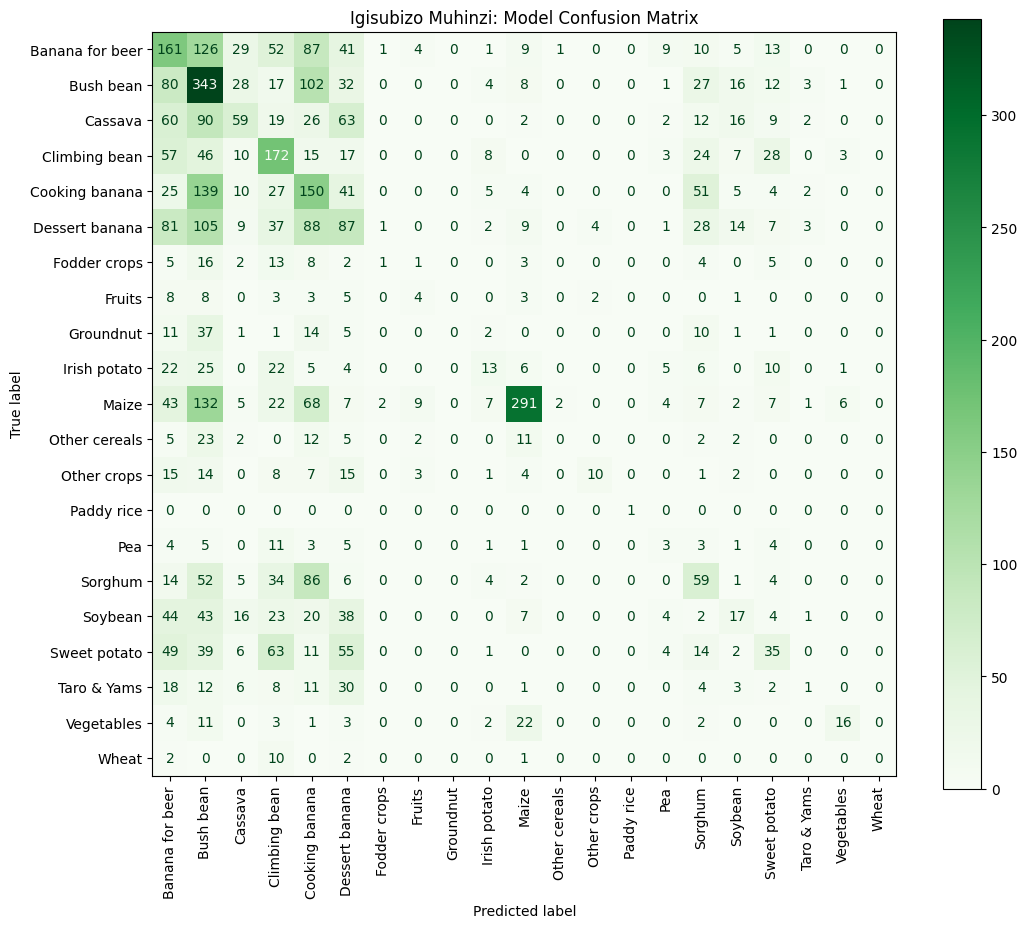

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting for the "Technical Execution" score
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_crop.classes_)
disp.plot(cmap='Greens', xticks_rotation='vertical', ax=ax)

plt.title('Igisubizo Muhinzi: Model Confusion Matrix')
plt.show()
